In [1]:
import numpy as np
from numpy.linalg import matrix_power
from scipy.stats import entropy as S
from scipy.linalg import expm
from scipy.special import softmax
import matplotlib.pyplot as plt

import os, sys, pathlib
os.environ["OPENBLAS_NUM_THREADS"] = "1"
_project_root = pathlib.Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[0]))
sys.path.insert(0, str(_project_root.parents[1]))
from physics.glauber import neighbors

In [3]:
import matplotlib as mpl
from itertools import product as iproduct
import matplotlib.pyplot as plt

mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 300,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Computer Modern Roman",
})

In [2]:
def pop(p0, G, N):
  p_avg = np.zeros_like(p0, dtype=float)

  for t in range(0, N):
    p_avg += matrix_power(G, t) @ p0

  return p_avg / N

def pmmc(p0, G, N):
  p_avg = pop(p0, G, N)
  GN = matrix_power(G, N)
  return (S(GN @ p0) - S(p0) + N * (S(p_avg) - S(G @ p_avg)))

def JS(distributions, base=np.e):
  P = np.asarray(distributions, dtype=float)
  P /= P.sum(axis=1, keepdims=True)

  M = P.mean(axis=0)

  return len(P) * S(M, base=base) - np.sum([S(p, base=base) for p in P])

In [ ]:
# ── Parameters ───────────────────────────────────────────────────────────────
L      = 3
shape  = (L, L)
N      = L * L
n_states = 1 << N

T1, T2 = 1/3, 1    # beta1*J = 0.5  (just above Tc, pi non-trivial)
                      # beta2*J = 0.25 (disordered but not flat)
                      # ratio 2x — meaningful but controlled
h     = 0.0    # no field — pi spread out, large KL(p0 || pi)
J     = 0.3
dt    = 0.1
N_max = 100

gamma  = 1.0
beta   = {1: 1/T1, 2: 1/T2}

# ── States ───────────────────────────────────────────────────────────────────
states    = [np.array(s, dtype=np.int8) for s in iproduct([-1, 1], repeat=N)]
n_states  = len(states)
state_idx = {tuple(s): k for k, s in enumerate(states)}

# def dE_flip(sigma, i):
#     return 2.0 * sigma[i] * (J * sum(sigma[j] for j in neighbors(i)) + h)
# epsilon = 0.3   # their interaction parameter

def dE_flip(sigma, i):
  M = np.sum(sigma)
  return 2.0 * J * sigma[i] * (M - sigma[i]) / N

# ── Build K^nu ────────────────────────────────────────────────────────────────
def build_K(nu):
  K = np.zeros((n_states, n_states))
  for col, sigma in enumerate(states):
    for i in range(N):
      dE = dE_flip(sigma, i)
      r  = gamma * np.exp(-0.5 * beta[nu] * dE)
      sigma_new    = sigma.copy()
      sigma_new[i] *= -1
      row = state_idx[tuple(sigma_new)]
      K[row, col] += r
  np.fill_diagonal(K, 0)
  np.fill_diagonal(K, -K.sum(axis=0))
  return K

# ── Build heat vector g_nu ────────────────────────────────────────────────────
def build_heat_vector(nu):
  """g_nu[sigma] = sum_i k_i^nu(sigma) * dE_i(sigma), so Qdot_nu = g_nu @ p."""
  g = np.zeros(n_states)
  for col, sigma in enumerate(states):
    for i in range(N):
      dE = dE_flip(sigma, i)
      r  = gamma * np.exp(-0.5 * beta[nu] * dE)
      g[col] += r * dE
  return g

# ── Entropy and KL helpers ────────────────────────────────────────────────────
def H_scalar(p):
  """Shannon entropy for a single 1D distribution. Avoids log(0) warnings."""
  mask = p > 0
  return -np.dot(p[mask], np.log(p[mask]))

def H_batch(P):
  """Shannon entropy for each row of a 2D array. Avoids log(0) warnings."""
  with np.errstate(divide='ignore', invalid='ignore'):
    logP = np.where(P > 0, np.log(P), 0.0)
  return -np.sum(P * logP, axis=1)

def KL_scalar(p, q):
  """KL(p || q) for two 1D distributions."""
  mask = p > 0
  return np.sum(p[mask] * np.log(p[mask] / q[mask]))

def KL_batch(P, q):
  """KL(P[i] || q) for each row of P against a fixed 1D distribution q."""
  with np.errstate(divide='ignore', invalid='ignore'):
    log_ratio = np.where(P > 0, np.log(np.where(P > 0, P, 1.0) / q), 0.0)
  return np.sum(P * log_ratio, axis=1)

# ── EP cost and optimal prior ─────────────────────────────────────────────────
def EP_cost(p, G, c):
  """Sigma(p) = H(Gp) - H(p) - c @ p."""
  return H_scalar(G @ p) - H_scalar(p) - c @ p

def find_optimal_prior(G, c, tol=1e-13, maxiter=10000, damping=0.5):
  """
  Find q* = argmin EP_cost(q, G, c) via damped fixed-point iteration.

  KKT condition:  q* ∝ exp(c + G^T log(G q*))

  Returns q*, residual EP at q*, and diagnostic info.
  """
  G, c = np.asarray(G), np.asarray(c)
  n = G.shape[0]
  q = np.ones(n) / n

  for it in range(maxiter):
    Gq   = G @ q
    z    = c + G.T @ np.log(Gq)
    q_fp = softmax(z)
    q_new = (1.0 - damping) * q + damping * q_fp

    if np.linalg.norm(q_new - q, ord=1) < tol:
      q = q_new
      break
    q = q_new

  # KKT residual — gradient must be constant across states at optimum
  grad     = np.log(q) - G.T @ np.log(G @ q) - c
  lagrange = q @ grad
  kkt      = np.max(np.abs(grad - lagrange))

  residual_EP = EP_cost(q, G, c)

  return q, residual_EP, {
      "iterations":   it + 1,
      "kkt_residual": kkt,
      "converged":    kkt < 1e-8,
  }

# ── Precompute everything ─────────────────────────────────────────────────────
print("Building K1, K2 ...")
K1 = build_K(1)
K2 = build_K(2)
K  = K1 + K2

print("Building heat vectors ...")
g1 = build_heat_vector(1)
g2 = build_heat_vector(2)

print("Computing matrix exponentials (once each) ...")

# Single-step propagator
G_dt = expm(K * dt)

# Block matrix for EP precomputation
# exp([[K^T, g^T],[0,0]] * t) offdiag block = integral_0^t e^{K^T s} g ds
ns      = n_states
n_baths = 2
g_mat   = np.stack([g1, g2])                   # (2, ns)

M       = np.zeros((ns + n_baths, ns + n_baths))
M[:ns, :ns] = K.T
M[:ns, ns:] = g_mat.T

EM_dt     = expm(M * dt)                       # step once, then iterate
betas_arr = np.array([beta[1], beta[2]])

# c for a single dt step — needed by find_optimal_prior
A_1step = EM_dt[:ns, ns:].T                    # (2, ns)
c_1step = betas_arr @ A_1step                  # (ns,)

# ── Find q_phys ───────────────────────────────────────────────────────────────
print("Finding optimal prior q* ...")
q_phys, residual_step, info = find_optimal_prior(G_dt, c_1step)
print(f"  converged={info['converged']}, iterations={info['iterations']}, "
      f"KKT residual={info['kkt_residual']:.2e}, residual EP/step={residual_step:.6f}")

Gq_phys = G_dt @ q_phys

# ── Initial condition ─────────────────────────────────────────────────────────
# p0 = np.ones(n_states) / n_states

# delta function — all spins up (larger KL, more interesting dynamics)
p0 = np.zeros(n_states)
p0[state_idx[tuple(np.ones(N, dtype=np.int8))]] = 1.0

# ── Trajectory ───────────────────────────────────────────────────────────────
print("Computing trajectory ...")
pts    = np.zeros((N_max + 1, n_states))
pts[0] = p0
for t in range(1, N_max + 1):
    pts[t] = G_dt @ pts[t-1]

# ── PMMC ──────────────────────────────────────────────────────────────────────
Ns      = np.arange(1, N_max + 1)
p_avgs  = np.cumsum(pts[:-1], axis=0) / Ns[:, None]   # (N_max, ns)
Gp_avgs = p_avgs @ G_dt.T

pmmcs = (
    H_batch(pts[1:])
    - H_scalar(p0)
    + Ns * (H_batch(p_avgs) - H_batch(Gp_avgs))
)

# ── EP curve — semigroup iteration, no extra expm calls ──────────────────────
print("Computing EP curve ...")
EM_n     = np.eye(ns + n_baths)
ep_curve = np.zeros(N_max)

for n in range(N_max):
    EM_n        = EM_n @ EM_dt
    A_n         = EM_n[:ns, ns:].T              # (2, ns)
    c_n         = betas_arr @ A_n               # (ns,)
    ep_curve[n] = H_scalar(pts[n+1]) - H_scalar(p0) - c_n @ p0

# Decomposition: Total EP = MC(q*) + N * residual_step
# so MC(q*) is the "extractable" part of EP relative to the optimal reference.
mc_steps       = KL_batch(pts[:-1], q_phys) - KL_batch(pts[1:], Gq_phys)
mc_phys        = np.cumsum(mc_steps)
residual_curve = Ns * residual_step

# verify decomposition holds
max_err = np.max(np.abs(ep_curve - mc_phys - residual_curve))
print(f"  error (should be ~0): {max_err:.2e}")

# ── Stationary state ──────────────────────────────────────────────────────────
vals, vecs = np.linalg.eig(K)

idx = np.argmin(np.abs(vals))
pi  = np.real(vecs[:, idx])
pi  = np.clip(pi / pi.sum(), 0, None)

kl = S(p0, pi)

# Computing the SLT
# escape rates vector
lam = -np.diag(K)           # lambda(sigma) = -K(sigma|sigma)

# block matrix for activity integral
# same structure as EP precomputation but with lam instead of g
M_act = np.zeros((ns + 1, ns + 1))
M_act[:ns, :ns] = K.T
M_act[:ns, ns]  = lam       # single vector, not two baths

EM_act_dt = expm(M_act * dt)

# then accumulate step by step alongside EM_n
EM_act_n = np.eye(ns + 1)
speed_limit = np.zeros(N_max)

for n in range(N_max):
    EM_act_n  = EM_act_n @ EM_act_dt
    a_n       = EM_act_n[:ns, ns]           # integral_0^{n*dt} e^{Ks} lam ds
    A_n       = a_n @ p0                    # scalar, expected total activity

    p_n       = pts[n + 1]
    TV_n      = np.sum(np.abs(p_n - p0))

    speed_limit[n] = TV_n**2 / (2 * A_n)

Building K1, K2 ...
Building heat vectors ...
Computing matrix exponentials (once each) ...
Finding optimal prior q* ...
  converged=True, iterations=74, KKT residual=4.16e-13, residual EP/step=0.053012
Computing trajectory ...
Computing EP curve ...
  error (should be ~0): 2.25e-12


In [5]:
print(kl)

3.952765042932231


In [6]:
second = np.exp(sorted(vals)[-2])
#print(np.exp(sorted(vals)))
time = (1/(1-second))/dt
print(round(time))
print(S(pts[round(time)+5], pi))

12
0.002084417112101812


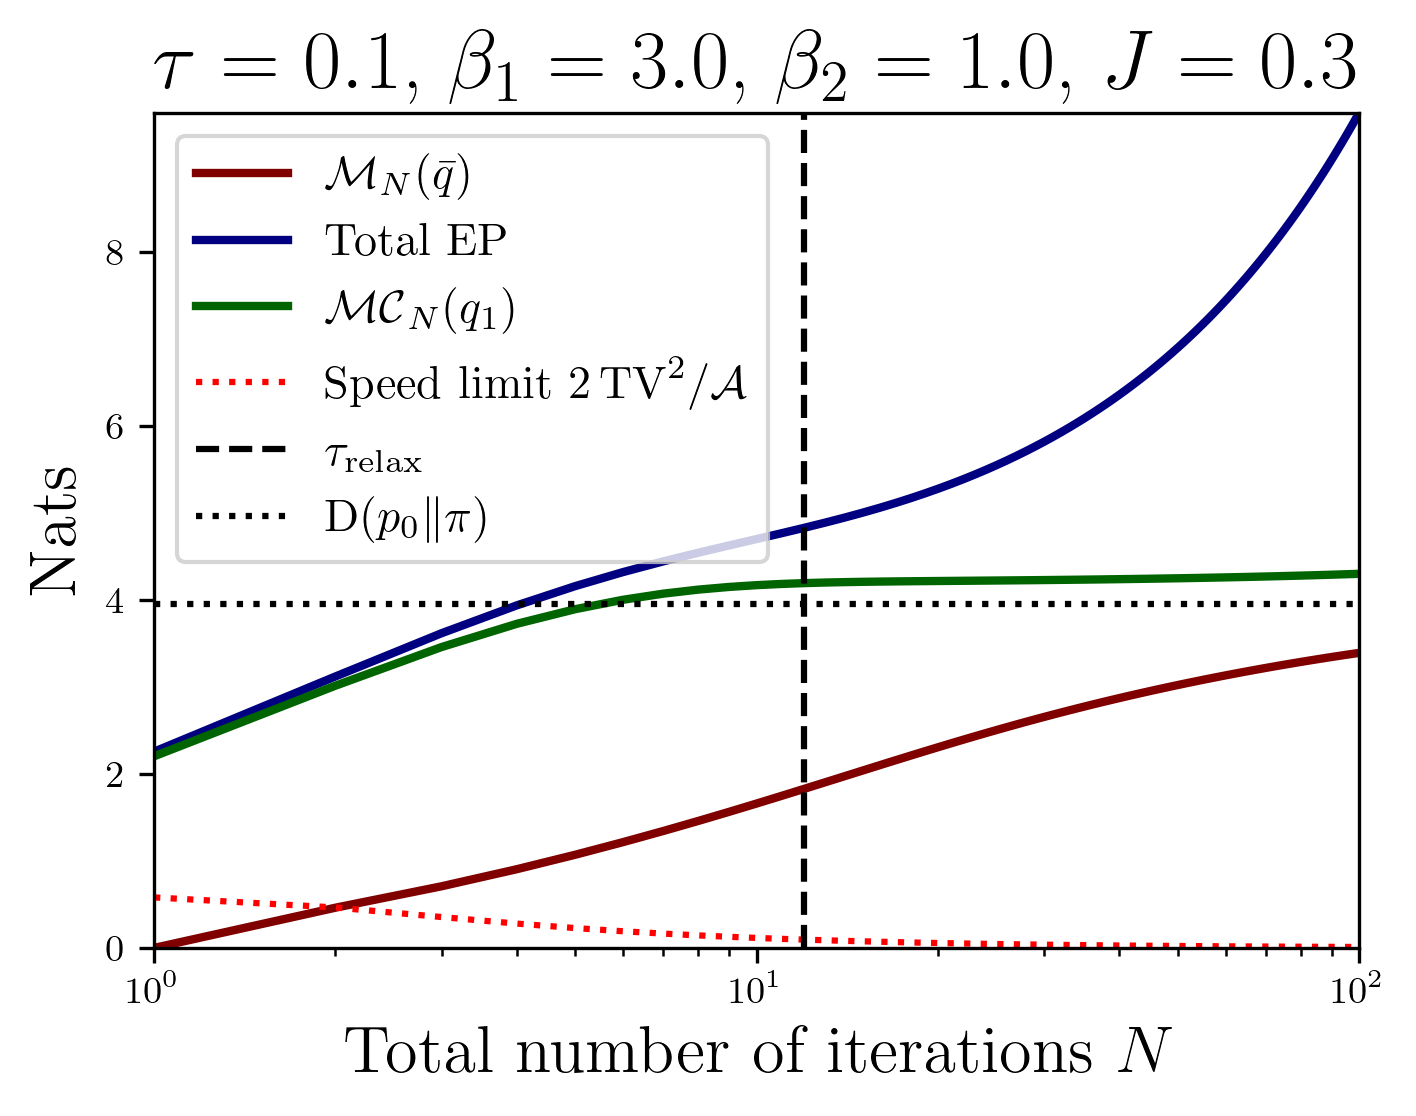

Done.


In [8]:
# ── Plot ──────────────────────────────────────────────────────────────────────
second = np.exp(sorted(vals)[-2])
time = (1/(1-second))/dt

fig, ax = plt.subplots(figsize=(5, 4))

ax.semilogx(Ns, pmmcs,          label=r'$\mathcal{M}_N(\bar{q})$',                    lw=2, color='maroon')
ax.semilogx(Ns, ep_curve,       label=r'Total EP',                             lw=2,   color='navy')
ax.semilogx(Ns, mc_phys,        label=r'$\mathcal{MC}_N(q_1)$',                 lw=2,   color='darkgreen')
ax.semilogx(Ns, speed_limit, label=r'Speed limit $2\,\mathrm{TV}^2/\mathcal{A}$',
        lw=1.5, linestyle=':', color='red')

ax.vlines(x=np.round(time), color = 'black', linestyles='dashed', lw=1.5, ymin=0, ymax = ep_curve[-1], label=r'$\tau_{\mathrm{relax}}$')

ax.hlines(
    y=kl, xmin=Ns[0], xmax=Ns[-1],
    color='black', linestyles='dotted', lw=1.5,
    label=r'$\mathrm{D}(p_0 \| \pi)$'
)

ax.set_xlabel(r'Total number of iterations $N$')
ax.set_ylabel(r'Nats')
ax.set_ylim(0,ep_curve[-1])
ax.set_title(fr'$\tau={dt}$, $\beta_1={beta[1]}$, $\beta_2={beta[2]}$, $J={J}$')
ax.legend(fontsize='x-small')
ax.set_xlim(Ns[0], Ns[-1])
plt.tight_layout()
# plt.savefig('/Users/benjmainansbacher/Documents/POP projectg/spins.pdf')
plt.show()
print("Done.")


In [ ]:
eps=np.array([-0.1,-0.1,0.2])
qbar=np.array([0.5,0.5,0])

print(S(qbar, qbar+eps))

0.2231435513142097
